In [1]:
import mediapipe as mp

In [19]:
from mediapipe import solutions
from mediapipe.framework.formats import landmark_pb2
import numpy as np


def draw_landmarks_on_image(rgb_image, detection_result):
  pose_landmarks_list = detection_result.pose_landmarks
  annotated_image = np.copy(rgb_image)

  # Loop through the detected poses to visualize.
  for idx in range(len(pose_landmarks_list)):
    pose_landmarks = pose_landmarks_list[idx]

    # Draw the pose landmarks.
    pose_landmarks_proto = landmark_pb2.NormalizedLandmarkList()
    pose_landmarks_proto.landmark.extend([
      landmark_pb2.NormalizedLandmark(x=landmark.x, y=landmark.y, z=landmark.z) for landmark in pose_landmarks
    ])
    solutions.drawing_utils.draw_landmarks(
      annotated_image,
      pose_landmarks_proto,
      solutions.pose.POSE_CONNECTIONS,
      solutions.drawing_styles.get_default_pose_landmarks_style())
  return annotated_image

In [4]:
from utils import get_all_measurements

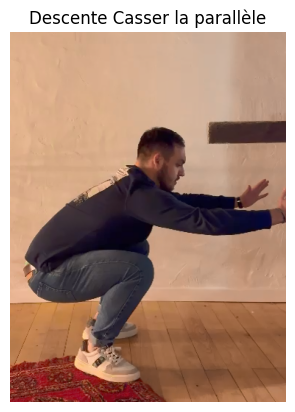

In [1]:

import cv2
import matplotlib.pyplot as plt

img = cv2.imread("data/reference/descente-fin.png")
image_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Display using matplotlib
plt.imshow(image_rgb)
plt.axis('off')  # Hide axes
plt.title("Descente Casser la parallèle")
plt.show()

In [12]:
# extraire les points via mediapipe
# STEP 1: Import the necessary modules.
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

# STEP 2: Create an PoseLandmarker object.
base_options = python.BaseOptions(model_asset_path='pose_landmarker_heavy.task')
options = vision.PoseLandmarkerOptions(
    base_options=base_options,
    output_segmentation_masks=True)
detector = vision.PoseLandmarker.create_from_options(options)

# STEP 3: Load the input image.
image = mp.Image.create_from_file("data/reference/descente-1.png")

# STEP 4: Detect pose landmarks from the input image.
detection_result = detector.detect(image)


In [13]:
landmarks = detection_result.pose_landmarks

In [31]:
if detection_result.pose_landmarks:
    landmarks = np.array([[landmark.x, landmark.y, landmark.z] for landmark in detection_result.pose_landmarks[0]])

In [32]:
landmarks

array([[ 0.60227603,  0.14453596, -0.12829384],
       [ 0.60215539,  0.11857885, -0.11969446],
       [ 0.59937006,  0.11672512, -0.12043194],
       [ 0.59727252,  0.1150268 , -0.12027601],
       [ 0.59766436,  0.11743951, -0.17128256],
       [ 0.5923717 ,  0.11571842, -0.17199434],
       [ 0.58670479,  0.11409226, -0.17217745],
       [ 0.5603615 ,  0.11348483, -0.02088051],
       [ 0.54336214,  0.11233971, -0.24928327],
       [ 0.5859471 ,  0.16163811, -0.07485773],
       [ 0.58019334,  0.15876132, -0.14701489],
       [ 0.5302043 ,  0.22442387,  0.13887669],
       [ 0.47684237,  0.19799033, -0.35459864],
       [ 0.64684248,  0.28721714,  0.22388577],
       [ 0.66400218,  0.26316601, -0.53017569],
       [ 0.80381787,  0.31133604,  0.19223823],
       [ 0.87348545,  0.26712924, -0.57514948],
       [ 0.83586848,  0.30708826,  0.20471171],
       [ 0.9298718 ,  0.26326108, -0.67835498],
       [ 0.84189457,  0.30242577,  0.12305257],
       [ 0.93361217,  0.24756528, -0.617

In [33]:
res = get_all_measurements(landmarks)

In [34]:
res

{'right_knee_bend': 117.679667126953,
 'left_knee_bend': 113.5153096548182,
 'right_knee_ankle_alignment': 0.07222491502761841,
 'left_knee_ankle_alignment': 0.0632522702217102,
 'back_arch': 72.96154779875437,
 'tailbone_tilt': 35.08861446872419,
 'stance_width': 0.5462415405481911,
 'hip_square': 78.42826556396889,
 'shoulder_alignment': 83.83707291230576,
 'weight_distribution': 0.3612472129757375,
 'spine_vertical': 40.31187831388815,
 'pelvis_tilt': 180.0,
 'right_knee_over_toes': 0.14849783890503349,
 'left_knee_over_toes': 0.11297969103586358,
 'right_elbow_angle': 146.58770929396638,
 'left_elbow_angle': 132.23653281462492,
 'head_neck_alignment': 56.530163960746336,
 'hip_shoulder_alignment': 75.64656515851036,
 'hand_foot_distance': 1.475744510116089,
 'hip_height': 0.4765753298997879,
 'symmetry': 0.1694468048711618,
 'core_engagement': 0.4488053462279233,
 'leg_engagement': 0.8108859364129171,
 'height': 0.8175298006756517,
 'angle_between_legs': 36.83198390826136,
 'right_

In [35]:
def calculate_distance_between_shoulders(landmarks: np.ndarray) -> float:
    """Calculate the distance between the feet"""
    left_shoulder = landmarks[mp.solutions.pose.PoseLandmark.LEFT_SHOULDER.value]
    right_shoulder = landmarks[mp.solutions.pose.PoseLandmark.RIGHT_SHOULDER.value]

    # Calculate the distance between the ankles
    distance = np.linalg.norm(left_shoulder - right_shoulder)
    return distance

In [36]:
calculate_distance_between_shoulders(landmarks)

0.497055460761623

In [ ]:
# check alignement pieds/épaules

# get angles back, right knee, left knee

# check 

In [19]:
# STEP 5: Process the detection result. In this case, visualize it.
annotated_image = draw_landmarks_on_image(img, detection_result)
# cv2_imshow(cv2.cvtColor(annotated_image, cv2.COLOR_RGB2BGR))

NameError: name 'cv2_imshow' is not defined

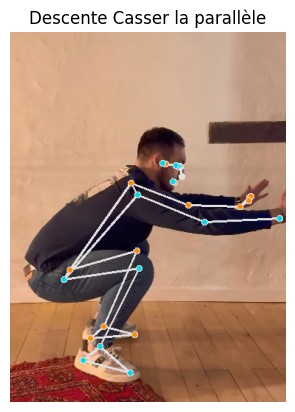

In [20]:
# Display using matplotlib
plt.imshow(cv2.cvtColor(annotated_image, cv2.COLOR_RGB2BGR))
plt.axis('off')  # Hide axes
plt.title("Descente Casser la parallèle")
plt.show()